In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

### Why Seaborn?

- provides a layer of abstraction hence simpler to use
- better aesthetics
- more graphs included

### Seaborn Roadmap

Types of Functions

- Figure Level
- Axis Level

Main Classification

- Relational Plot
- Distribution Plot
- Categorical Plot
- Regression Plot
- Matrix Plot
- Multiplots

https://seaborn.pydata.org/api.html

### 1. Relational Plot

- to see the statistical relation between 2 or more variables.
- Bivariate Analysis

Plots under this section

- scatterplot
- lineplot

In [145]:
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


<Axes: xlabel='total_bill', ylabel='tip'>

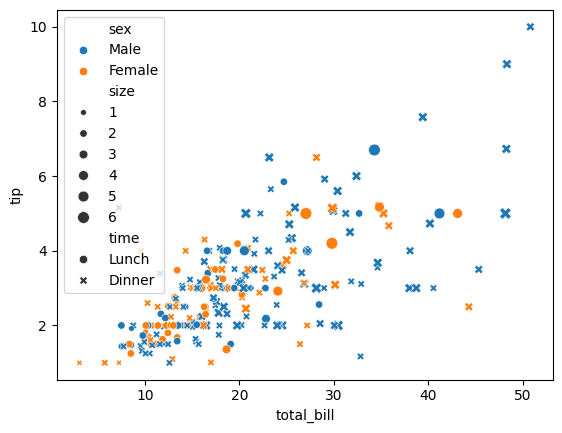

In [146]:
# scatter plot ---> axis level function
sns.scatterplot(data = tips, x='total_bill', y='tip',hue='sex',style='time',size='size')

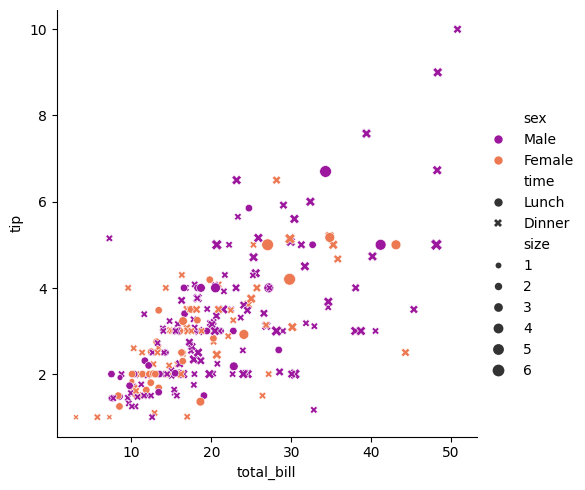

In [147]:
# relplot ---> figure level function
sns.relplot(data=tips,x='total_bill', y='tip',kind='scatter',hue='sex',style='time',size='size',palette='plasma')

In [148]:
gap = px.data.gapminder()
gap

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4
...,...,...,...,...,...,...,...,...
1699,Zimbabwe,Africa,1987,62.351,9216418,706.157306,ZWE,716
1700,Zimbabwe,Africa,1992,60.377,10704340,693.420786,ZWE,716
1701,Zimbabwe,Africa,1997,46.809,11404948,792.449960,ZWE,716
1702,Zimbabwe,Africa,2002,39.989,11926563,672.038623,ZWE,716


<Axes: xlabel='year', ylabel='lifeExp'>

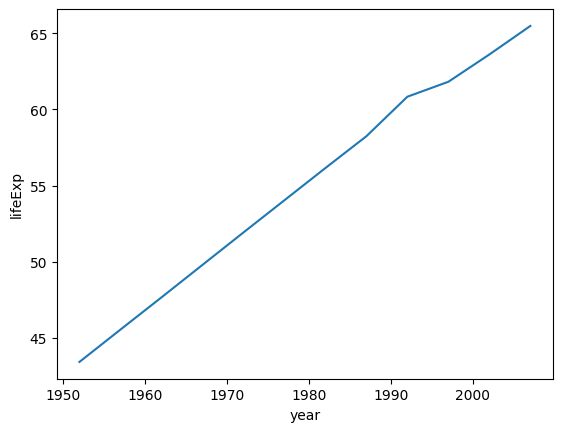

In [149]:
# line plot ----> axis level function
pak_df = gap[gap['country'] == 'Pakistan']
sns.lineplot(data=pak_df,x='year',y='lifeExp')

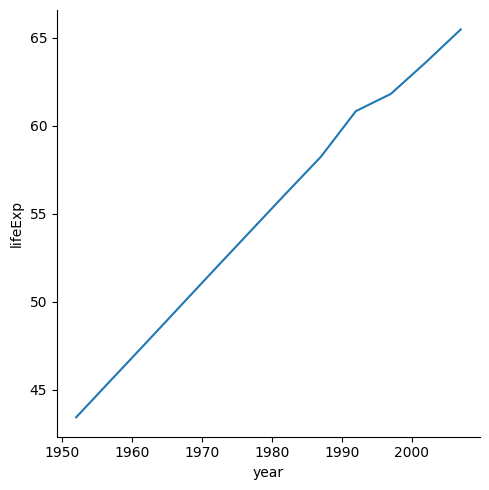

In [150]:
# relplot ---> figure level function
sns.relplot(data=pak_df,x='year',y='lifeExp',kind='line')

In [151]:
# hue & style
temp_df = gap[gap['country'].isin(['Pakistan','Brazil','Germany'])]
temp_df.sample(5)

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
173,Brazil,Americas,1977,61.489,114313951,6660.118654,BRA,76
175,Brazil,Americas,1987,65.205,142938076,7807.095818,BRA,76
179,Brazil,Americas,2007,72.390,190010647,9065.800825,BRA,76
569,Germany,Europe,1977,72.500,78160773,20512.921230,DEU,276
1175,Pakistan,Asia,2007,65.483,169270617,2605.947580,PAK,586


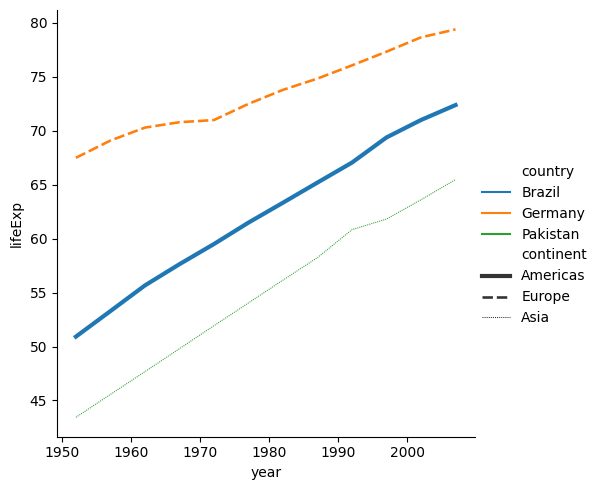

In [152]:
sns.relplot(data=temp_df,x='year',y='lifeExp',kind='line',hue='country',style='continent',size='continent')

<Axes: xlabel='year', ylabel='lifeExp'>

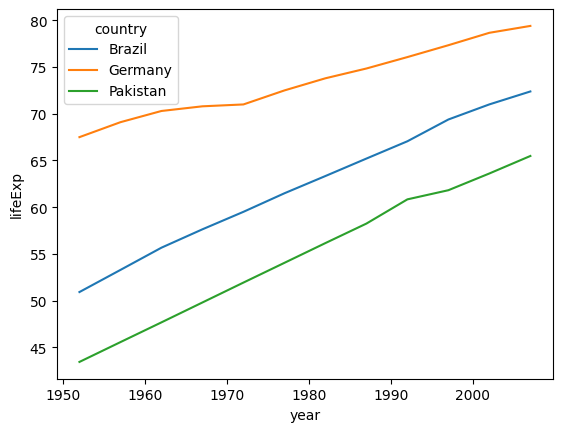

In [153]:
sns.lineplot(data=temp_df,x='year',y='lifeExp',hue='country')

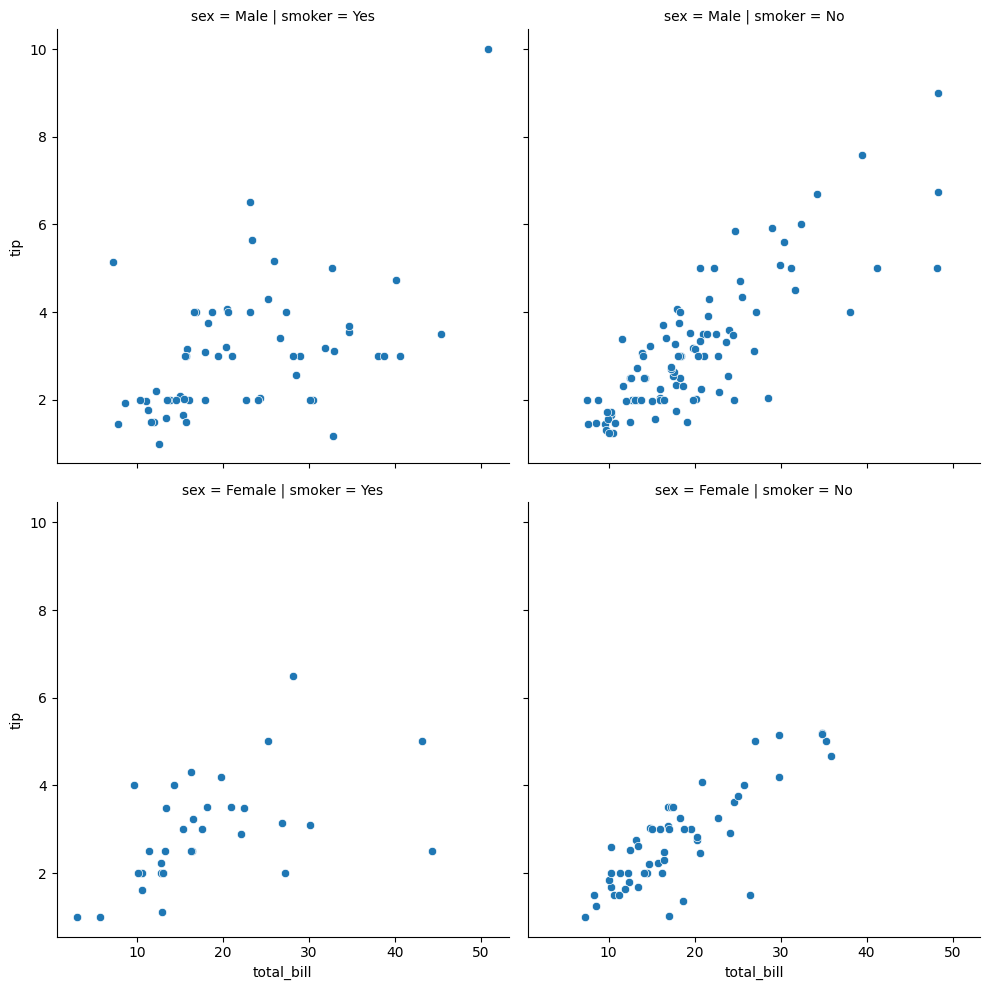

In [154]:
# facet plot --> col & row Only works on relplot (fig level func)
sns.relplot(data=tips,x='total_bill',y='tip',col='smoker',row='sex',kind='scatter')

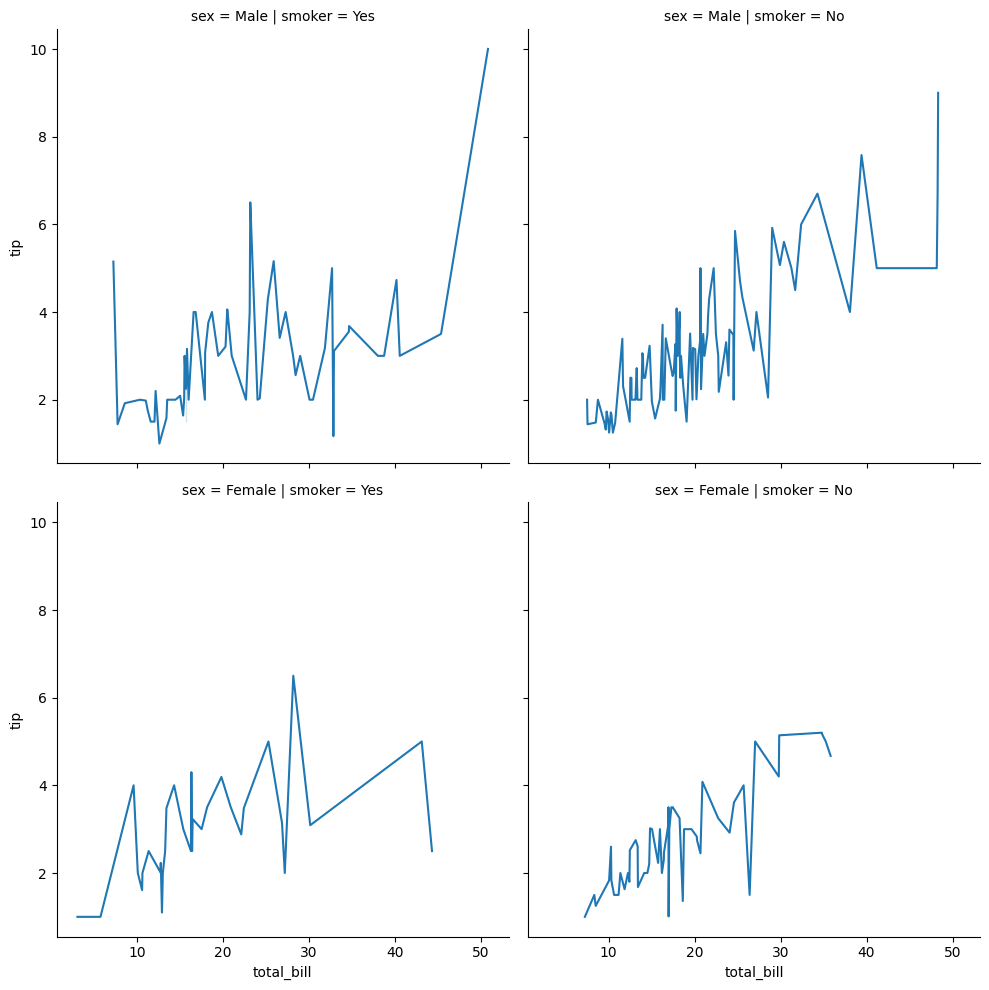

In [155]:
# facet plot --> col & row Only works on relplot (fig level func)
sns.relplot(data=tips,x='total_bill',y='tip',col='smoker',row='sex',kind='line')

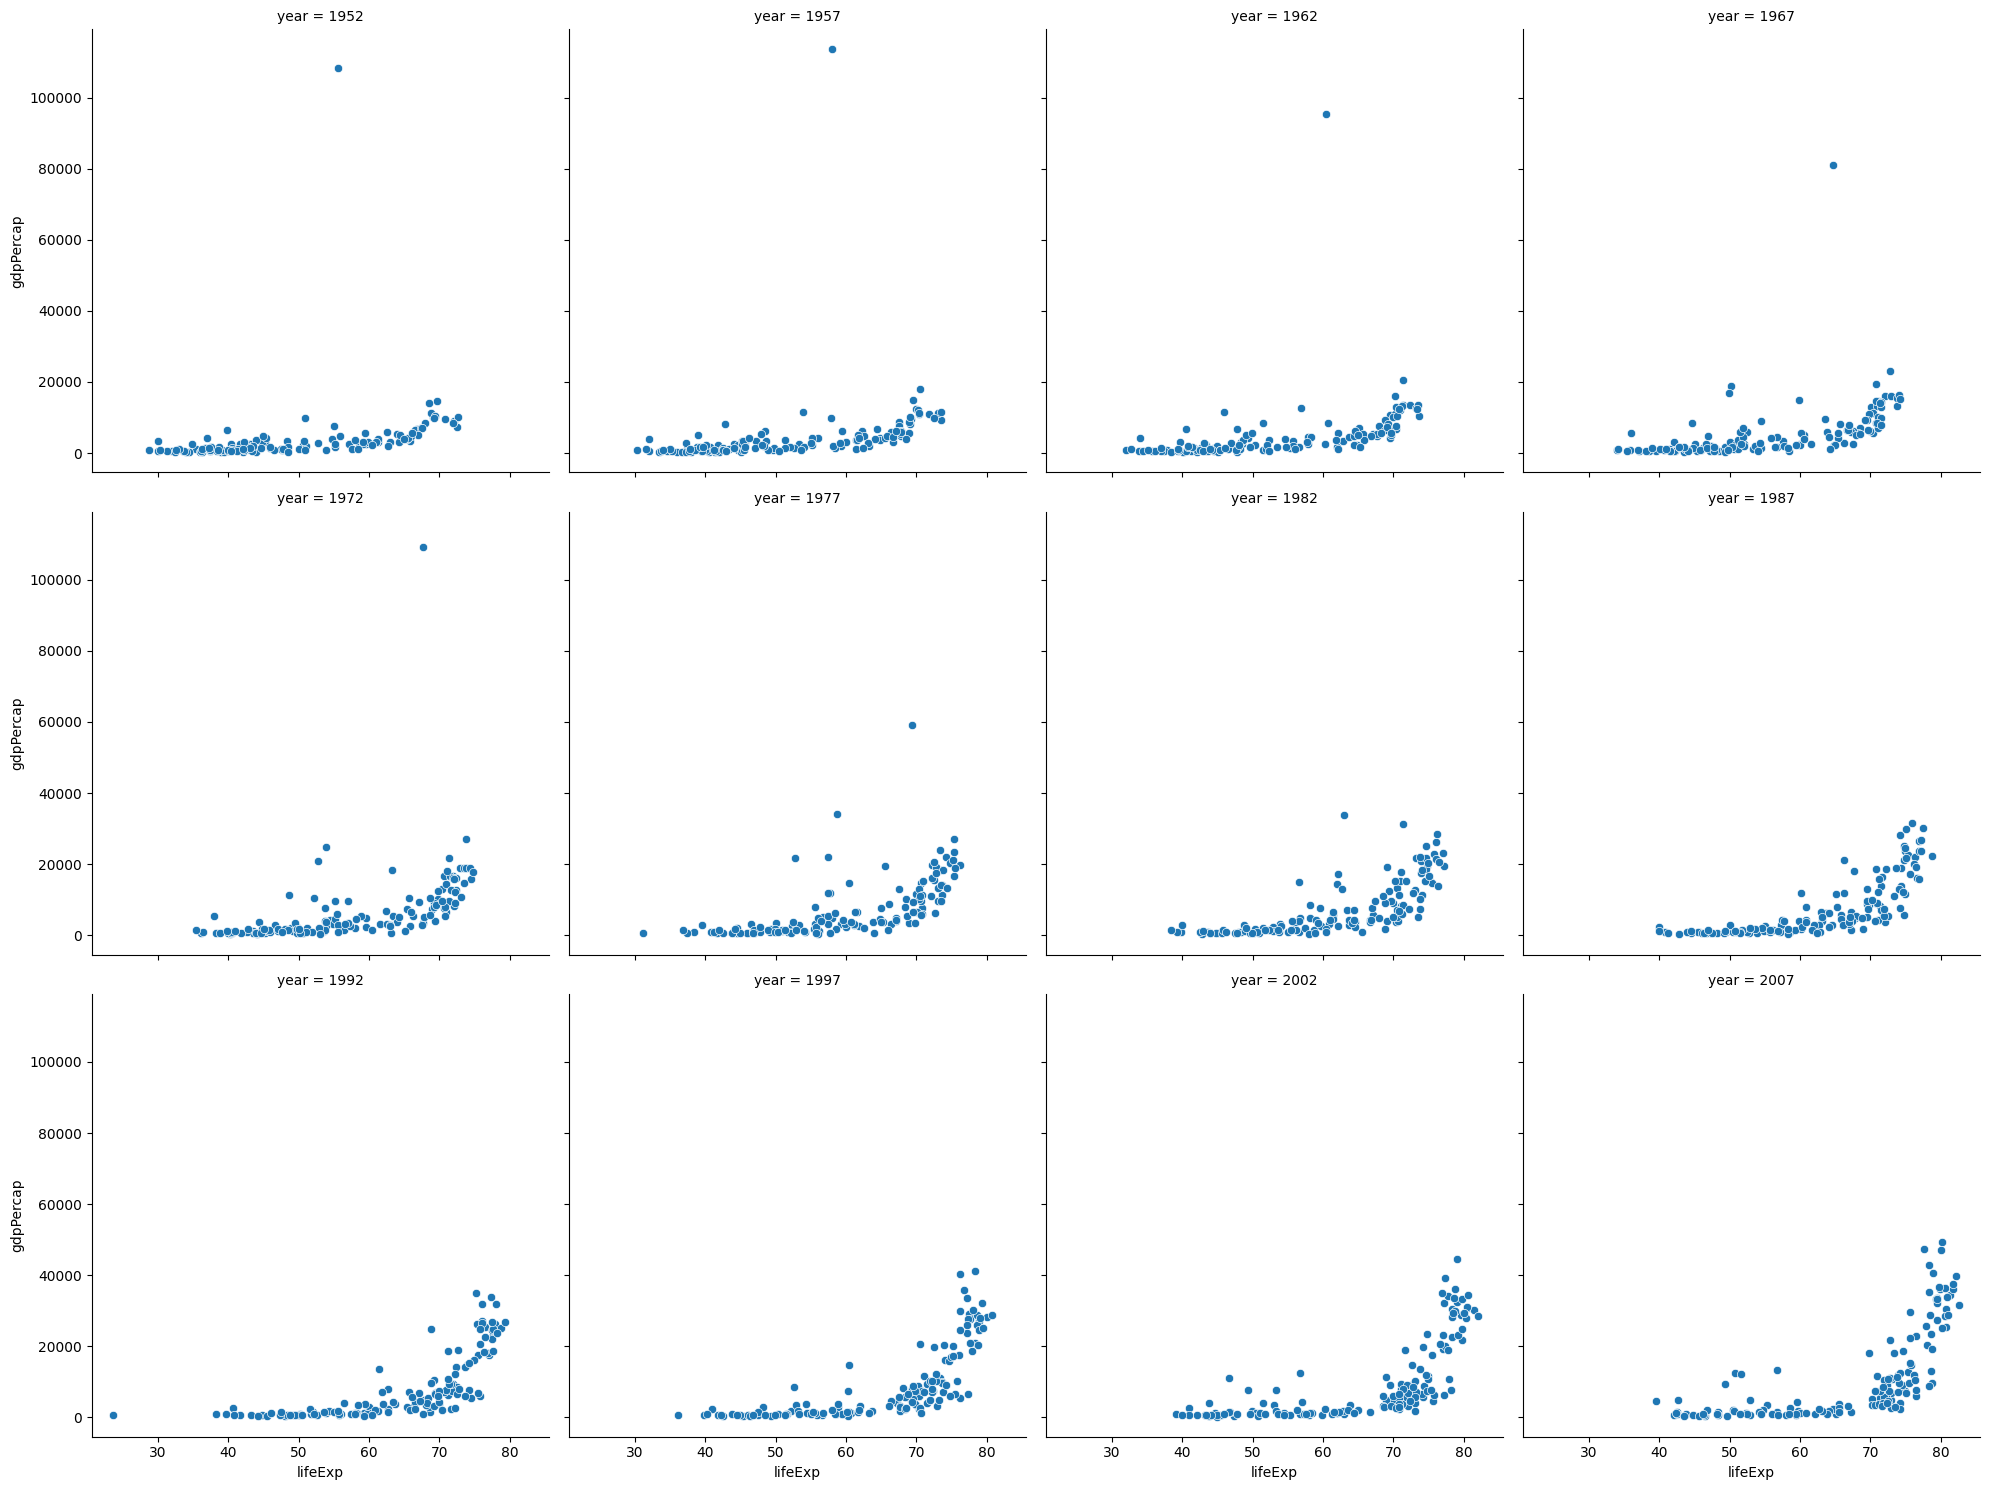

In [156]:
# col wrap
sns.relplot(data=gap,x='lifeExp',y='gdpPercap',col='year',col_wrap=4)

### 2. Distribution Plots

- used for univariate analysis
- used to find out the distribution
- Range of the observation
- Central Tendency
- is the data bimodal?
- Are there outliers?

Plots under distribution plot

- histplot
- kdeplot
- rugplot

In [157]:
# figure level  ---> displot
# axis level    ---> histplot, kdeplot and rugplot

<Axes: xlabel='total_bill', ylabel='Count'>

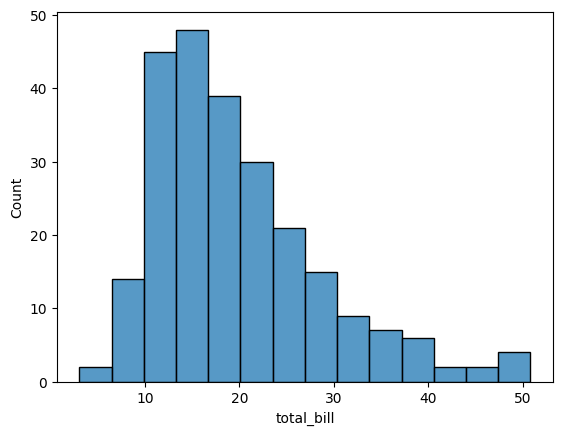

In [174]:
# ploting univariate hist plot (axis level)
sns.histplot(data=tips,x='total_bill')

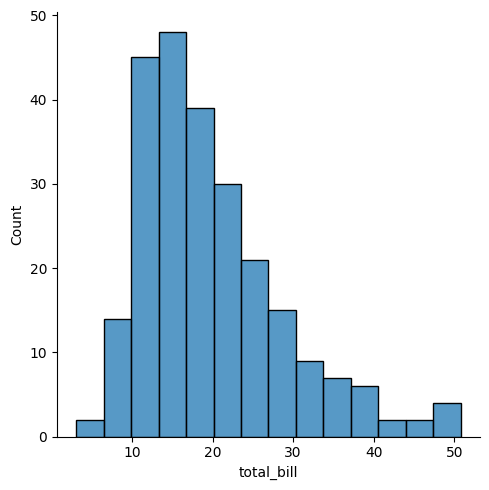

In [163]:
# figure level hist plot
sns.displot(data=tips,x='total_bill',kind='hist')

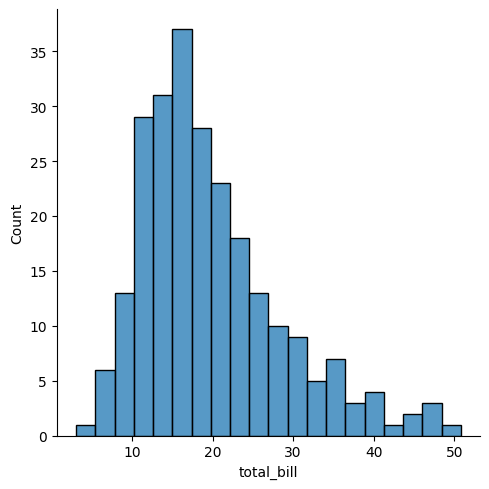

In [164]:
# bins parameter
sns.displot(data=tips,x='total_bill',kind='hist',bins=20)

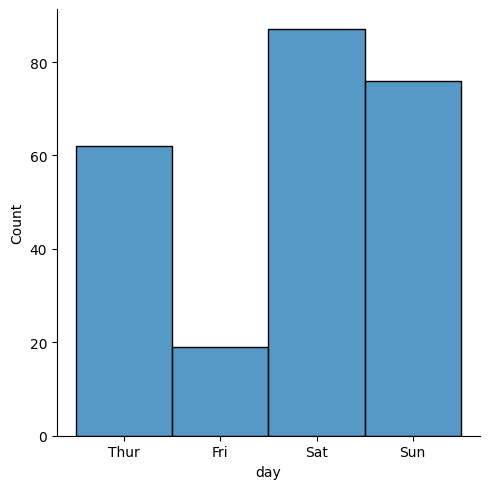

In [189]:
# histogram on categorical column is possible using seaborn
# work like a count plot
sns.displot(data=tips,x='day',kind='hist')

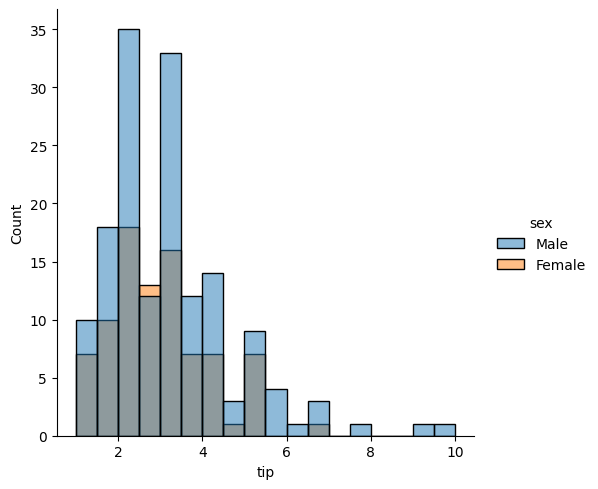

In [166]:
# hue parameter
sns.displot(data=tips,x='tip',kind='hist',hue='sex')

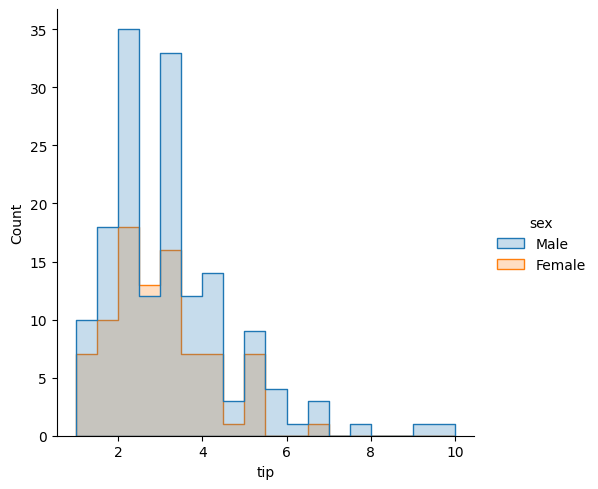

In [169]:
# element parameter
sns.displot(data=tips,x='tip',kind='hist',hue='sex',element='step')

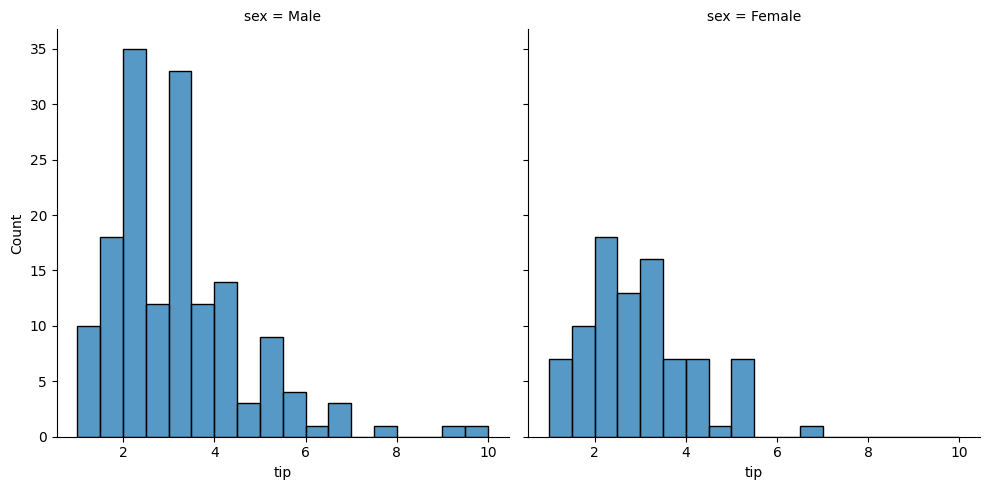

In [175]:
# facet only works with figure
sns.displot(data=tips,x='tip',kind='hist',col='sex')

<Axes: xlabel='tip', ylabel='Density'>

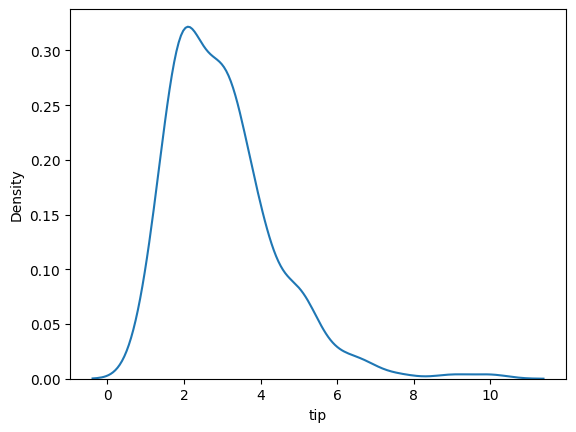

In [180]:
# kdeplot
# Rather than using discrete bins, a KDE plot smooths the observations with a Gaussian kernel, producing a continuous density estimate
sns.kdeplot(data=tips,x='tip')

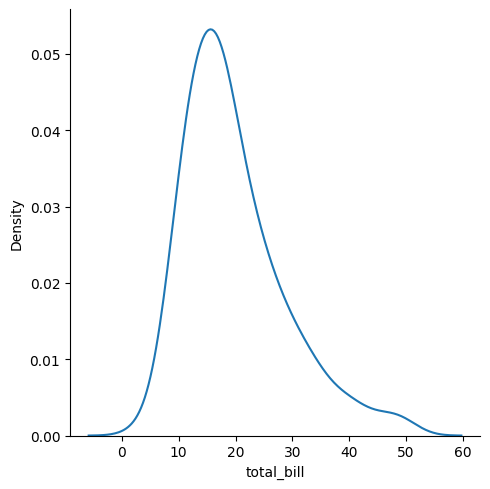

In [177]:
sns.displot(data=tips,x='total_bill',kind='kde')

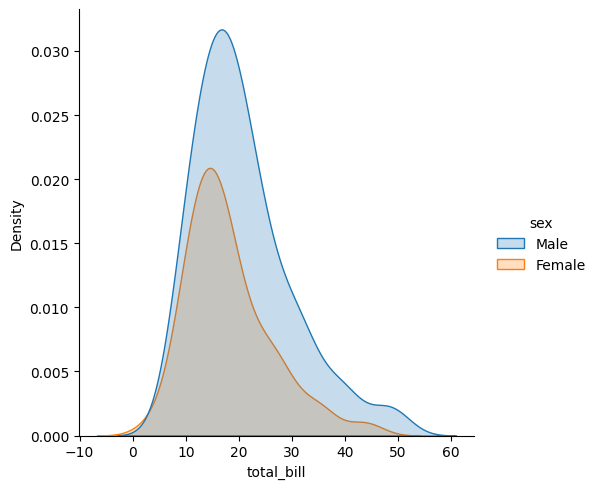

In [191]:
# hue parameter and fill
sns.displot(data=tips,x='total_bill',hue='sex',fill=True,kind='kde')

<Axes: xlabel='total_bill', ylabel='Density'>

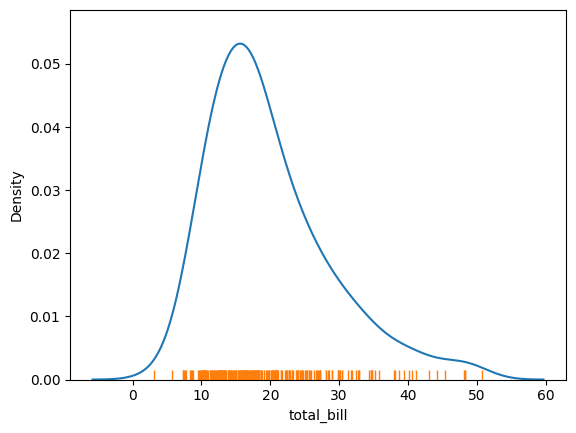

In [192]:
# Rugplot
# Plot marginal distributions by drawing ticks along the x and y axes.
# This function is intended to complement other plots by showing the location of individual observations in an unobtrusive way.
sns.kdeplot(data=tips,x='total_bill')
sns.rugplot(data=tips,x='total_bill')

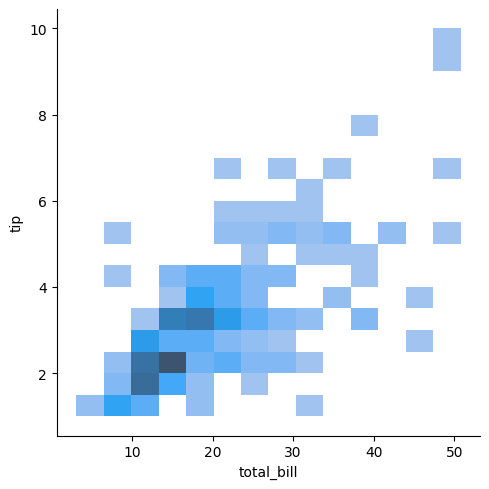

In [195]:
# Bivariate histogram
# A bivariate histogram bins the data within rectangles that tile the plot
# and then shows the count of observations within each rectangle with the fill color

# sns.histplot(data=tips, x='total_bill', y='tip')
sns.displot(data=tips,x='total_bill',y='tip',kind='hist')

<Axes: xlabel='total_bill', ylabel='tip'>

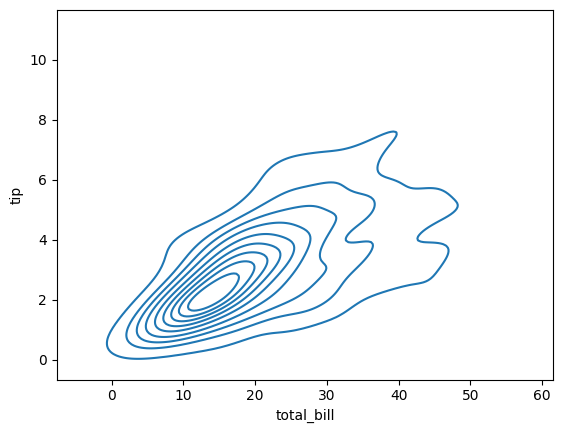

In [196]:
# Bivariate Kdeplot
# a bivariate KDE plot smoothes the (x, y) observations with a 2D Gaussian
sns.kdeplot(data=tips,x='total_bill',y='tip')

### 3. Matrix Plot

- Heatmap
- Clustermap

<Axes: xlabel='year', ylabel='country'>

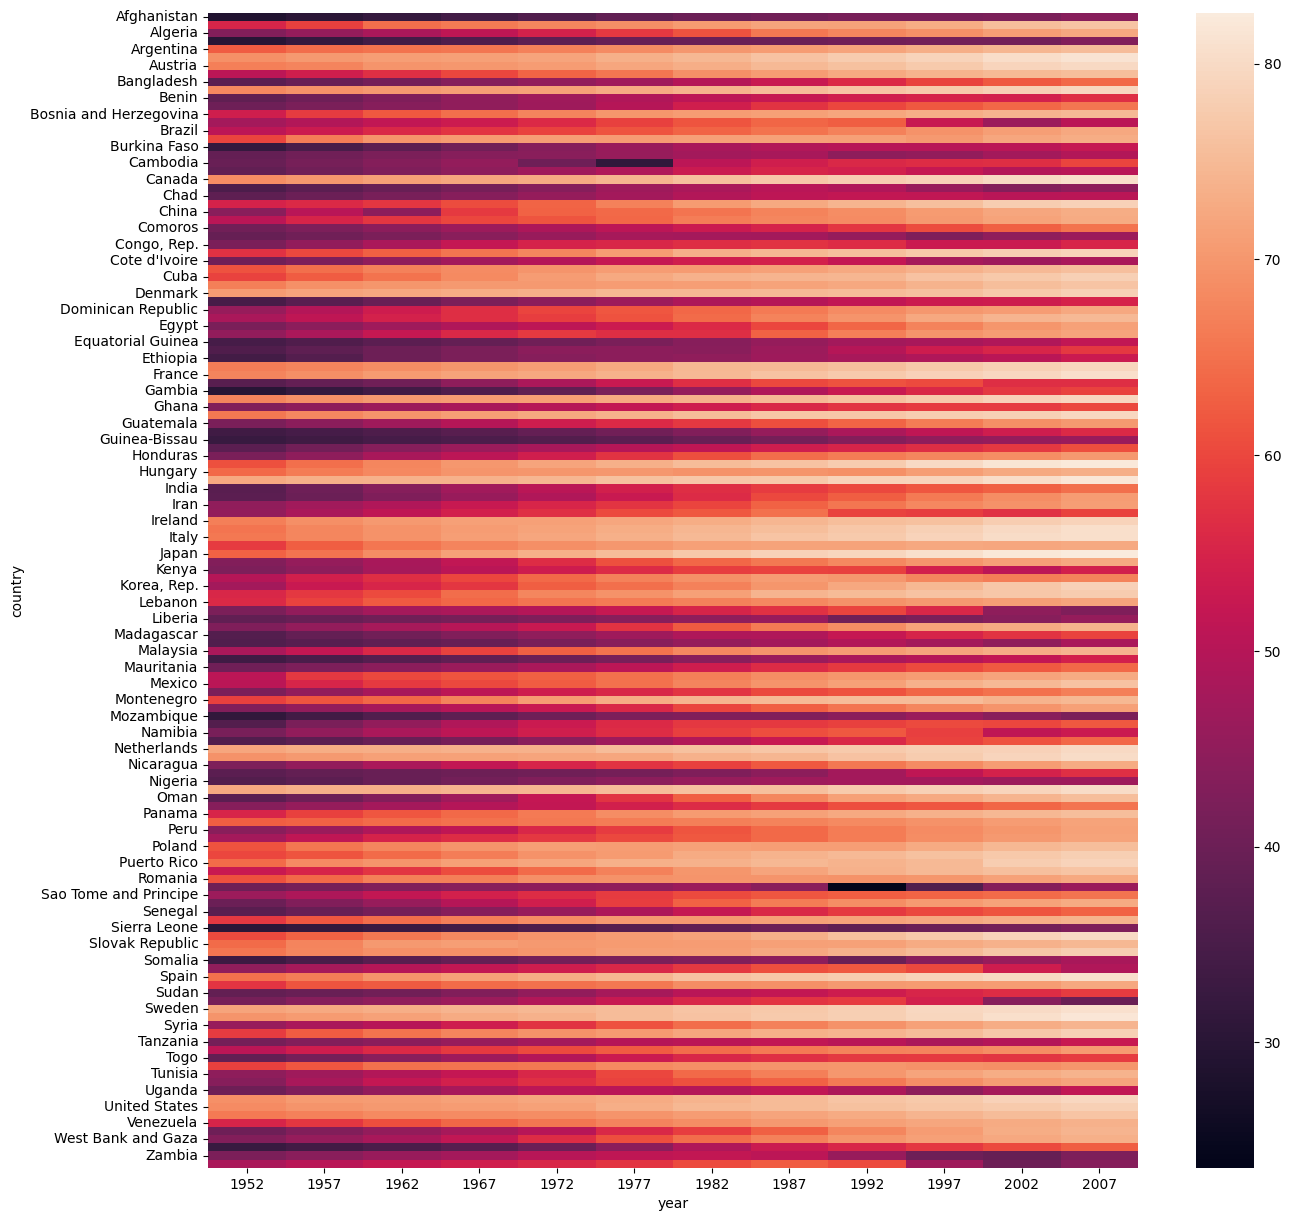

In [202]:
# Heatmap
# Plot rectangular data as color-encoded matrix
temp_df = gap.pivot(index='country',columns='year',values='lifeExp')
# axis level function
plt.figure(figsize=(15,15))
sns.heatmap(temp_df)

<Axes: xlabel='year', ylabel='country'>

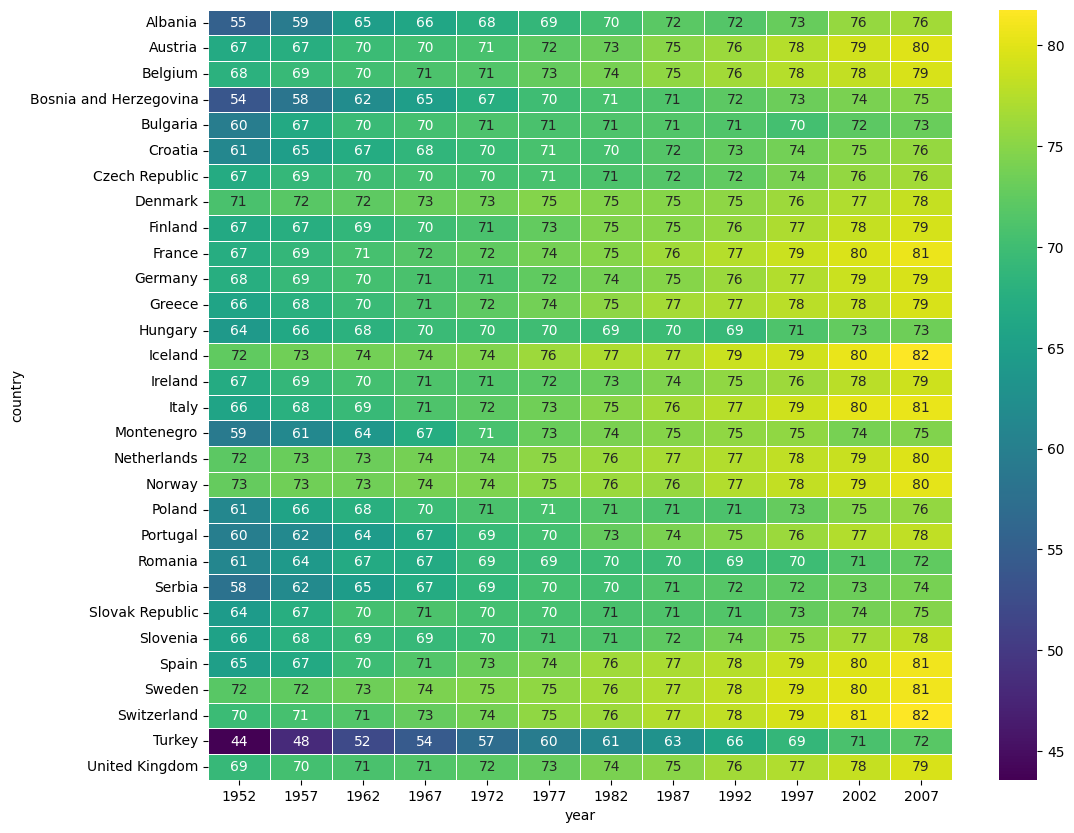

In [220]:
# annot & linewidth
temp_df = gap[gap['continent'] == 'Europe'].pivot(index='country',columns='year',values='lifeExp')
plt.figure(figsize=(12,10))
sns.heatmap(temp_df,annot=True,linewidth=0.5,cmap='viridis')

In [221]:
# Clustermap
# Plot a matrix dataset as a hierarchically-clustered heatmap.
# This function requires scipy to be available.
iris = px.data.iris()
iris

,sepal_length,sepal_width,petal_length,petal_width,species,species_id
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,3
146,6.3,2.5,5.0,1.9,virginica,3
147,6.5,3.0,5.2,2.0,virginica,3
148,6.2,3.4,5.4,2.3,virginica,3


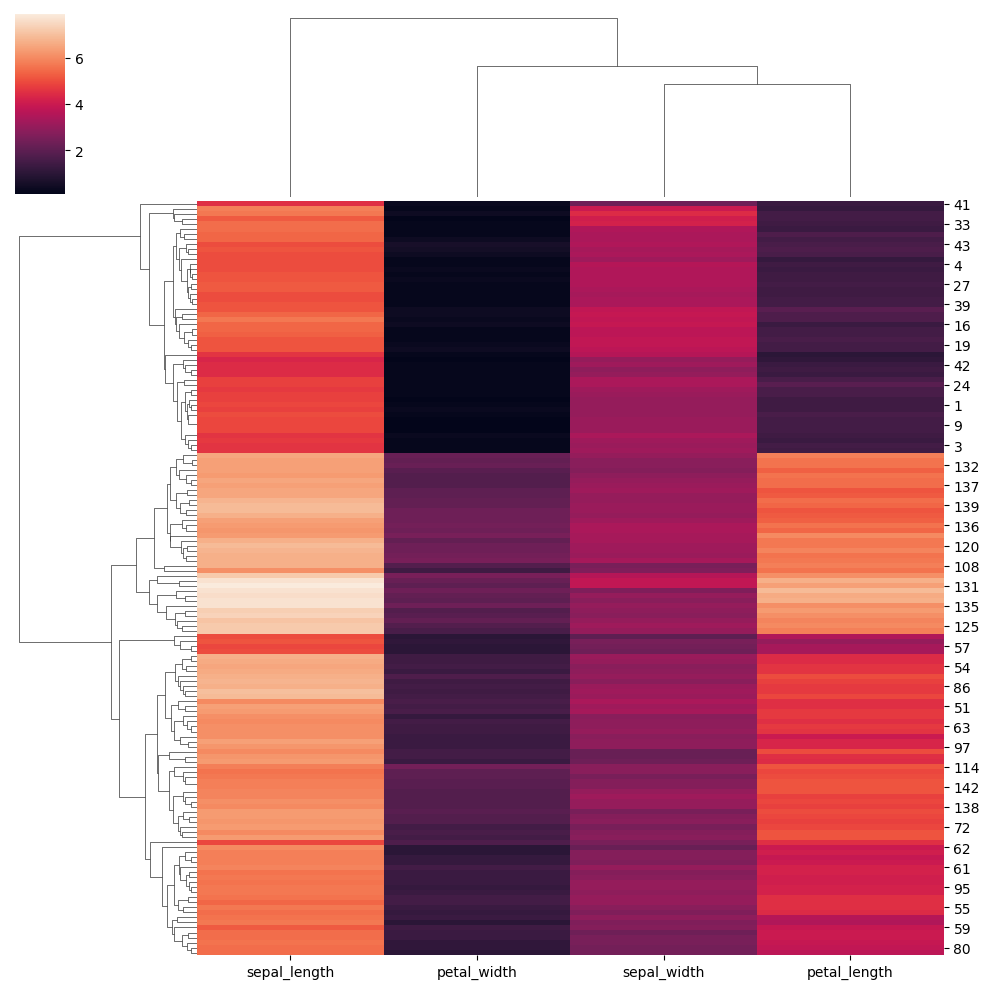

In [233]:
sns.clustermap(iris.iloc[:,:4])